In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
trader = pd.read_csv("../data/historical_data.csv")
sentiment = pd.read_csv("../data/fear_greed.csv")

# Preview data
print(trader.head())

print(sentiment.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [10]:
# Convert trader date

trader['Timestamp IST'] = pd.to_datetime(
    trader['Timestamp IST'],
    dayfirst=True
)

# Convert sentiment date
sentiment['date'] = pd.to_datetime(sentiment['date'])

# Create common Date column
trader['Date'] = trader['Timestamp IST'].dt.date
sentiment['Date'] = sentiment['date'].dt.date

print("Date conversion successful")

Date conversion successful


In [9]:
print(sentiment.columns)

Index(['timestamp', 'value', 'classification', 'date', 'Date'], dtype='str')


In [ ]:
# Merge Data


merged = pd.merge(
    trader,
    sentiment,
    on='Date',
    how='inner'
)

print(merged.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side       Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-12-02 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-12-02 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-12-02 22:50:00     1289.488521       Buy   

   Closed PnL  ...     Order ID  Crossed       Fee      Trade ID  \
0         0.0  ...  5201

In [12]:
# Profit Analysis
print(
    merged.groupby('classification')['Closed PnL'].mean()
)


classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64


In [13]:
# Trade Count
print(
    merged.groupby(['classification', 'Side']).size()
)

classification  Side
Extreme Fear    BUY     10935
                SELL    10465
Extreme Greed   BUY     17940
                SELL    22052
Fear            BUY     30270
                SELL    31567
Greed           BUY     24576
                SELL    25727
Neutral         BUY     18969
                SELL    18717
dtype: int64


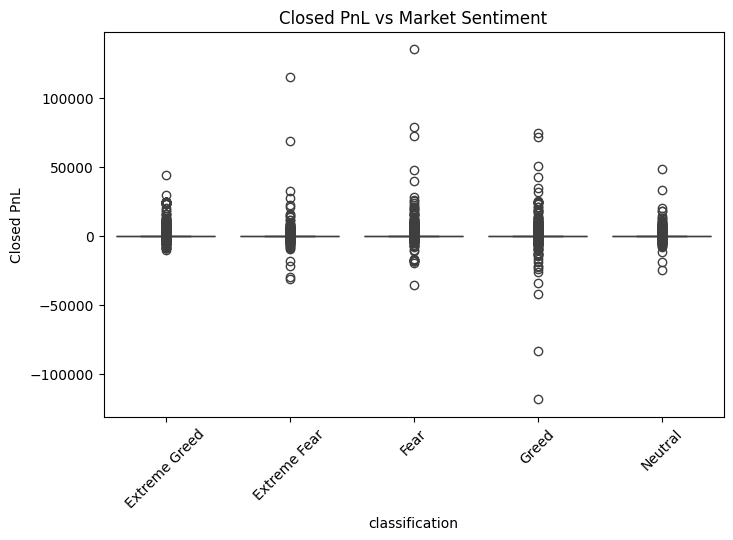

In [14]:
# Chart
plt.figure(figsize=(8,5))

sns.boxplot(
    x='classification',
    y='Closed PnL',
    data=merged
)

plt.title("Closed PnL vs Market Sentiment")

plt.xticks(rotation=45)

plt.show()

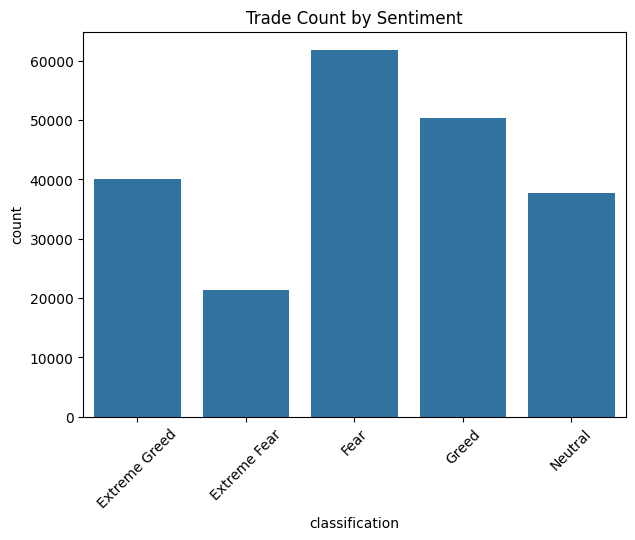

In [16]:
# Trade count chart

plt.figure(figsize=(7,5))

sns.countplot(
    x='classification',
    data=merged
)

plt.title("Trade Count by Sentiment")

plt.xticks(rotation=45)

plt.show()

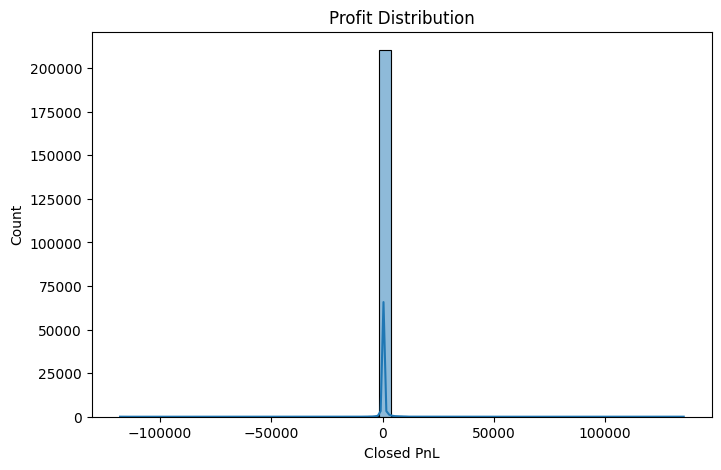

In [17]:
# Profit distribution chart

plt.figure(figsize=(8,5))

sns.histplot(
    merged['Closed PnL'],
    bins=50,
    kde=True
)

plt.title("Profit Distribution")

plt.show()

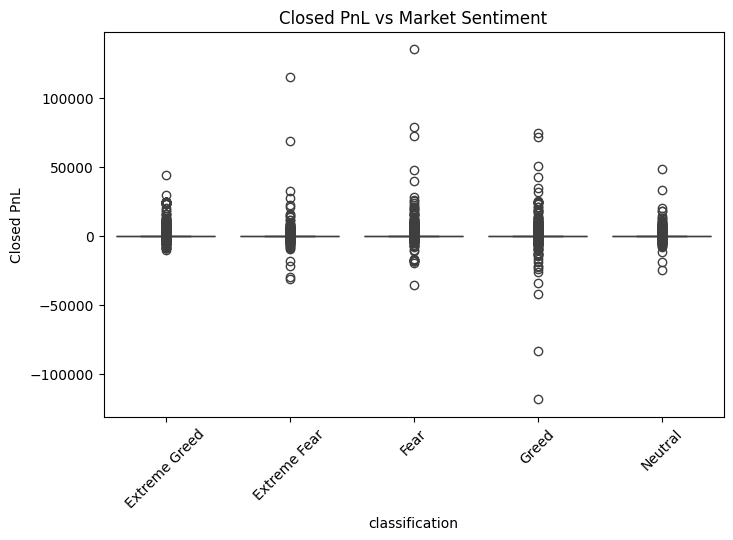

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='classification',
    y='Closed PnL',
    data=merged
)

plt.title("Closed PnL vs Market Sentiment")

plt.xticks(rotation=45)

# Save chart
plt.savefig("../outputs/pnl_vs_sentiment.png")

plt.show()